<a href="https://colab.research.google.com/github/saifbhatti004/AI-lab-task/blob/main/Lab_task_2_b_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

INDEX  | ACTUAL CROP  | PREDICTED CROP | NUTRIENT STATUS            | MATCH STATUS
1      | rice         | rice           | High-Nutrient Demand       | MATCH   
2      | rice         | rice           | High-Nutrient Demand       | MATCH   
3      | rice         | rice           | Moderate-Nutrient Balanced | MATCH   
4      | rice         | rice           | Moderate-Nutrient Balanced | MATCH   
5      | rice         | rice           | Moderate-Nutrient Balanced | MATCH   
6      | rice         | rice           | Moderate-Nutrient Balanced | MATCH   
7      | rice         | rice           | Moderate-Nutrient Balanced | MATCH   
8      | rice         | rice           | Low-Nutrient / Specialized | MATCH   
9      | rice         | rice           | Low-Nutrient / Specialized | MATCH   
10     | rice         | rice           | Moderate-Nutrient Balanced | MATCH   

--- PERFORMANCE EVALUATION SUMMARY ---
Total Dataset Records: 2200
Matching Decisions:   207
Mismatch Decisions:   1993
Accura

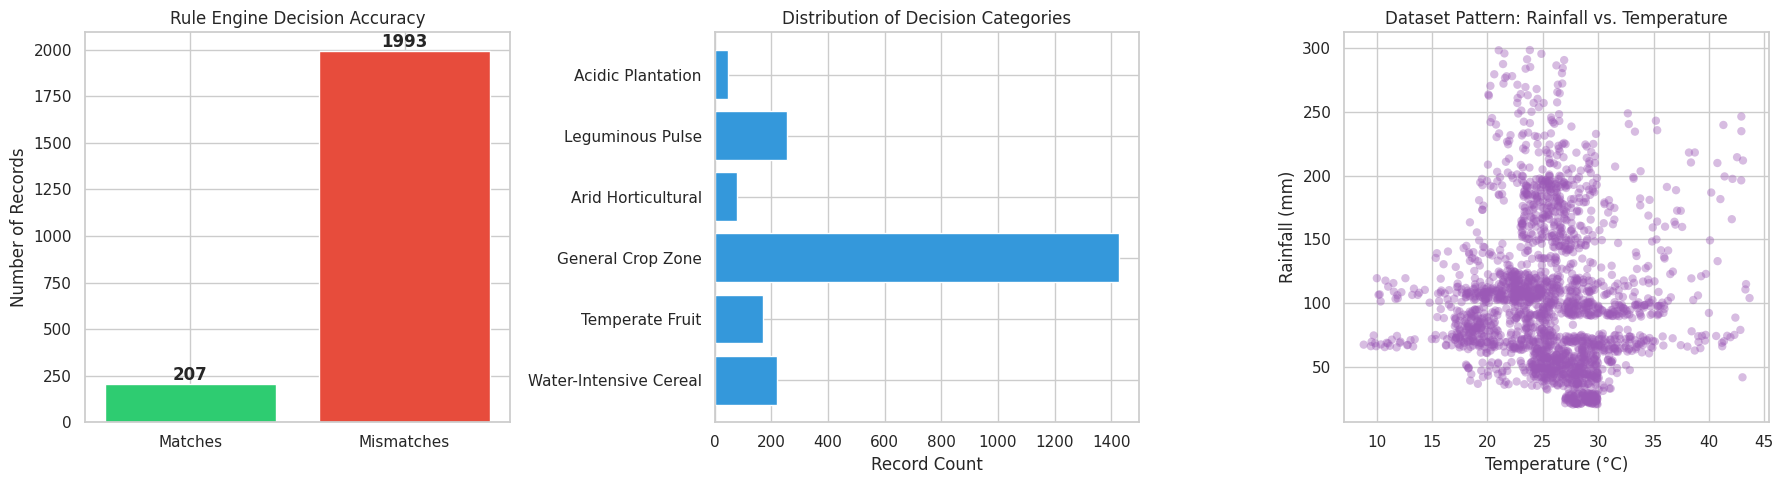

In [ ]:
import csv
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for visual graphics
sns.set_theme(style="whitegrid")

# ==========================================
# 1. CORE RULE-BASED DECISION LOGIC
# ==========================================

def evaluate_crop_suitability(n, p, k, temp, humidity, ph, rainfall):
    """
    Evaluates soil and climate parameters against agronomical heuristic bounds.
    """
    # Evaluate Nutrient Profile Status
    if n > 80 and p > 40 and k > 40:
        nutrient_status = "High-Nutrient Demand"
    elif 30 <= n <= 80 and 20 <= p <= 60 and 20 <= k <= 60:
        nutrient_status = "Moderate-Nutrient Balanced"
    else:
        nutrient_status = "Low-Nutrient / Specialized"

    # Rule-Set Evaluation for Crop Category Prediction
    if rainfall > 180 and humidity > 70 and temp > 20:
        rule_crop = "rice"
        suitability = "Water-Intensive Cereal"
    elif rainfall < 90 and temp > 25 and humidity < 60:
        rule_crop = "muskmelon"
        suitability = "Arid Horticultural"
    elif n < 40 and p > 50 and k > 40:
        rule_crop = "chickpea"
        suitability = "Leguminous Pulse"
    elif temp < 23 and humidity < 70 and rainfall < 110:
        rule_crop = "apple"
        suitability = "Temperate Fruit"
    elif n > 100 and k > 150:
        rule_crop = "grapes"
        suitability = "High-Potash Fruit"
    elif ph < 6.0 and rainfall > 150:
        rule_crop = "coffee"
        suitability = "Acidic Plantation"
    else:
        rule_crop = "maize"  # Fallback rule guess
        suitability = "General Crop Zone"

    return suitability, rule_crop, nutrient_status


# ==========================================
# 2. PIPELINE EXECUTION & DATA PROCESSING
# ==========================================

def run_crop_pipeline(file_path):
    dataset = []

    # Load Dataset via built-in csv module
    with open(file_path, mode='r') as file:
        reader = csv.DictReader(file)
        for row in reader:
            dataset.append({
                'N': float(row['N']),
                'P': float(row['P']),
                'K': float(row['K']),
                'temp': float(row['temperature']),
                'humidity': float(row['humidity']),
                'ph': float(row['ph']),
                'rainfall': float(row['rainfall']),
                'actual_label': row['label'].strip().lower()
            })

    total_records = len(dataset)
    matches = 0
    mismatches = 0

    predicted_crops = []
    actual_labels = []
    category_counts = {}

    print("=" * 95)
    print(f"{'INDEX':<6} | {'ACTUAL CROP':<12} | {'PREDICTED CROP':<14} | {'NUTRIENT STATUS':<26} | {'MATCH STATUS':<8}")
    print("=" * 95)

    # Process records
    for idx, sample in enumerate(dataset):
        suitability, predicted_crop, nutrient_status = evaluate_crop_suitability(
            sample['N'], sample['P'], sample['K'],
            sample['temp'], sample['humidity'], sample['ph'], sample['rainfall']
        )

        is_match = (predicted_crop == sample['actual_label'])
        if is_match:
            matches += 1
            status_str = "MATCH"
        else:
            mismatches += 1
            status_str = "MISMATCH"

        predicted_crops.append(predicted_crop)
        actual_labels.append(sample['actual_label'])
        category_counts[suitability] = category_counts.get(suitability, 0) + 1

        # Print the first 10 explicit records
        if idx < 10:
            print(f"{idx+1:<6} | {sample['actual_label']:<12} | {predicted_crop:<14} | {nutrient_status:<26} | {status_str:<8}")

    print("=" * 95)

    # Calculate metrics
    accuracy = (matches / total_records) * 100
    print("\n--- PERFORMANCE EVALUATION SUMMARY ---")
    print(f"Total Dataset Records: {total_records}")
    print(f"Matching Decisions:   {matches}")
    print(f"Mismatch Decisions:   {mismatches}")
    print(f"Accuracy Rate:        {accuracy:.2f}%\n")

    # Generate Graphs
    plot_analysis_charts(matches, mismatches, category_counts, dataset)


# ==========================================
# 3. VISUALIZATION & GRAPH GENERATION
# ==========================================

def plot_analysis_charts(matches, mismatches, category_counts, dataset):
    """Generates analytical charts for accuracy, distribution, and environmental parameters."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Graph 1: Rule Accuracy (Matches vs Mismatches)
    axes[0].bar(['Matches', 'Mismatches'], [matches, mismatches], color=['#2ecc71', '#e74c3c'])
    axes[0].set_title('Rule Engine Decision Accuracy')
    axes[0].set_ylabel('Number of Records')
    for i, v in enumerate([matches, mismatches]):
        axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

    # Graph 2: Rule Decision Category Distribution
    categories = list(category_counts.keys())
    counts = list(category_counts.values())
    axes[1].barh(categories, counts, color='#3498db')
    axes[1].set_title('Distribution of Decision Categories')
    axes[1].set_xlabel('Record Count')

    # Graph 3: Scatter Plot of Key Environmental Parameters (Rainfall vs Temp)
    temperatures = [d['temp'] for d in dataset]
    rainfalls = [d['rainfall'] for d in dataset]
    axes[2].scatter(temperatures, rainfalls, alpha=0.4, c='#9b59b6', edgecolors='none')
    axes[2].set_title('Dataset Pattern: Rainfall vs. Temperature')
    axes[2].set_xlabel('Temperature (°C)')
    axes[2].set_ylabel('Rainfall (mm)')

    plt.tight_layout()
    plt.show()

# Run script
run_crop_pipeline('/content/drive/MyDrive/AI LAB 2 DATASET/Crop_recommendation.csv')